Quantization

* Quantization reduces the precision of neural network weights and activations.
* It helps shrink model size, reduce memory usage, and improve inference speed.
* The main trade-off is a small reduction in model accuracy.
* Perplexity measures how well a language model predicts text.
* Lower perplexity means the model is more confident in its predictions.
* Large language models such as Meta LLaMA and TinyLlama are often evaluated on benchmarks like WikiText.
* Perplexity on these benchmarks is calculated over thousands of tokens.
* In practice, a smaller text sample is often enough to compare relative performance changes.
* After quantizing a model to 8-bit, we can check whether perplexity increases significantly.
* If perplexity rises only slightly while speed and memory usage improve, quantization is usually considered a good trade-off.
* This evaluation text is intentionally longer to provide enough tokens for testing.


Quantization is the process of reducing the precision of the numbers used to represent a model's weights. Large models have billions of parameters, and storing them all in FP32 format consumes significant resources. By quantizing to lower precision formats like FP16 or INT8, we can reduce memory usage and speed up inference and infra cost, often with minimal impact on model performance.

float point = -sign * mantissa * 2^(exponent)

| Format   | Total Bits | Sign Bits | Exponent Bits | Mantissa Bits | Notes                                    |
| -------- | ---------- | --------- | ------------- | ------------- | ---------------------------------------- |
| FP32     | 32         | 1         | 8             | 23            | High precision, large range              |
| FP16     | 16         | 1         | 5             | 10            | Lower precision, smaller range           |
| BFloat16 | 16         | 1         | 8             | 7             | FP32-like range, lower precision         |
| INT8     | 8          | 1         | 0             | 0             | Integer format, no exponent/mantissa     |
| INT4     | 4          | 1         | 0             | 0             | Very compact integer format              |
| NF4      | 4          | 1         | 3             | 0/implicit    | 4-bit floating-point quantization format |


NF4 is a 4-bit quantized floating format used mainly in LLM quantization.
It does not store full exponent/mantissa like FP formats.
Instead, 4-bit values map to precomputed floating-point values optimized for normally distributed weights.

The goal of quantization is to find the "sweet spot." For example, a mobile translation app running 

| Model Precision | Accuracy | Latency  | User Experience                   | Trade-off                                 |
| --------------- | -------- | -------- | --------------------------------- | ----------------------------------------- |
| FP32            | 99%      | 500 ms   | Accurate but slow                 | High precision, high compute cost         |
| INT8            | 98%      | 200 ms   | Fast and nearly identical quality | Best balance of speed & accuracy          |
| 4-bit Quantized | 90%      | Very low | Very fast but noticeable errors   | Extreme compression, larger accuracy drop |


# Weights

Every trained neural network is defined by its weights—the fixed numbers in its layers. The goal of weight quantization is to convert these weights from a high-precision format, like a 32-bit floating-point number (FP32), to a low-precision one, such as an 8-bit integer (INT8).

Weight quantization maps a wide range of floating-point values to a limited set of integers using a scale factor and zero-point offset, drastically reducing model size with minimal precision loss.

### symmetric quantization

- Model weights in FP32 = [-1.0, -0.5, 0.0, 0.5, 1.0]   # input
- INT8 range = [-128 to 127] # output

- Scale = max(input)/max(output) = 1/127 = 0.0078 = q

- Quantized weights = (input/scale) = [-1/q, -0.5/q, 0.0, 0.5/q, 1/q] = [-128, -64, 0, 64, 128]  

- Dequantized weights = quantized_weights * scale = [-128*q, -64*q, 0, 64*q, 128*q] = [-1.001, -0.5003, 0.0, 0.5003, 1.001]


Quantization Table

| FP32 Value (x) | INT8 Value (x1 = x/q) | Dequantized Value (x2 = x1 * q) |
| -------------- | ------------------------------- | ---------------------------------- |
| -1.0           | -127                            | -1.001                               |
| -0.5           | -64                             | -0.503                             |
| 0.0            | 0                               | 0.0                                |
| 0.5            | 64                              | 0.503                              |
| 1.0            | 127                             | 1.001                                |

Key Idea

* FP32 → accurate but large
* INT8 → smaller & faster
* Small rounding error = quantization noise
* Model size reduces by ~4x with minimal accuracy drop


### Unsymmetric quantization

- Model weights in FP32 = [2,3,4]   # input
- INT8 range = [0 to 255] # output

- Scale = q = (max(Input) - min(Input)) / (max(Output) - min(Output)) = (4-2)/(255-0) = 2/255 = 0.0078
- Zero-point = z = (min(Output) - min(Input)/q = (0 - 2)/0.0078 = -255 
- Quantized weights = (input/scale) + zero-point = [2/q - 255, 3/q - 255, 4/q - 255] = [0, 127, 255]
- Dequantized weights = (quantized_weights - zero-point) * scale = [(0 + 255)*q, (127 + 255)*q, (255 + 255)*q] = [2.001, 3.001, 4.002]

| Term       | Easy Meaning                                         |
| ---------- | ---------------------------------------------------- |
| Scale      | “How much real value does 1 integer step represent?” |
| Zero-Point | “Where should float value 0 map in integer space?”   |


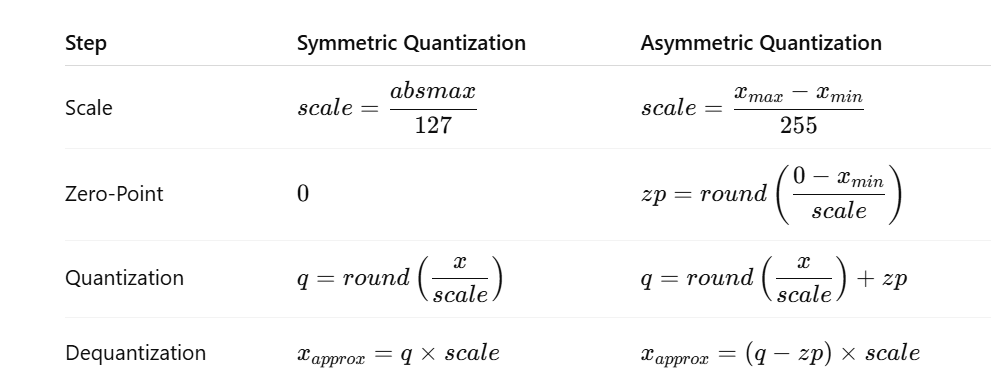

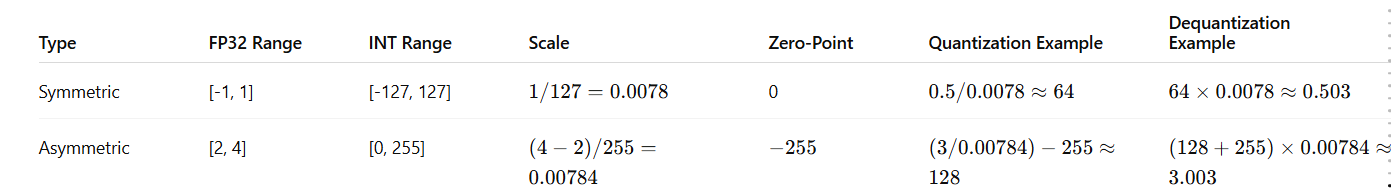

| Feature            | Symmetric Quantization                   | Asymmetric Quantization                                      |
| ------------------ | ---------------------------------------- | ------------------------------------------------------------ |
| Used When          | Values centered around 0                 | Values shifted away from 0                                   |
| Example Range      | [-1, 1]                                  | [2, 4]                                                       |
| Main Idea          | Equal steps around zero                  | Shift values to use full INT range                           |
| Advantage          | Simpler & faster                         | Better range utilization                                     |


| Component   | Usually Used            | Reason                                     |
| ----------- | ----------------------- | ------------------------------------------ |
| Weights     | Symmetric Quantization  | Weights are usually centered around 0      |
| Activations | Asymmetric Quantization | Activations are often shifted/non-negative |

* Symmetric → simpler & faster
* Asymmetric → better range utilization when data is shifted around 0

Activations are often: shifted,
mostly positive after ReLU/GELU, not centered around zero.

Example: [0.1, 2.3, 5.8]

Using asymmetric quantization:
utilizes full INT range better, preserves more information.

# Quantizing Activations and QKV Caches


LLM memory
- Model weights are fixed after training, so we can precompute their quantization parameters (scale/zero-point) and store them efficiently.
- Activations are the intermediate numerical values computed during each forward pass of the model.
- The KV Cache is an optimization technique used during autoregressive generation. It stores the Key (K) and Value (V) tensors for previous tokens in a sequence to avoid costly recomputation. For long sequences, this cache can grow to several gigabytes.

 - Both activations and the KV cache are dynamic. Their values are generated at runtime and change based on the specific input provided to the model. 
 - This dynamism means we cannot pre-calculate their quantization parameters (scale and zero-point) ahead of time.
 - Unlike static weights, dynamic values like activations and the KV cache must be quantized using a calibration step that observes their runtime range on a sample dataset.

The solution to this is a process called calibration. Calibration allows us to find a representative range for these dynamic values. The process involves four main steps:

- Prepare a Calibration Dataset: Select a small but representative sample of data (e.g., 100-200 examples) that reflects the kind of inputs the model will see in production. Ex = real-world prompts and feeding them through the model to observe the actual distribution of activation values.
- Run Inference: Feed the calibration dataset through the model.
- Collect Statistics: During the inference passes, record the minimum and maximum floating-point values observed for each activation tensor you intend to quantize.
- Calculate Scale & Zero-Point: Using the collected min/max ranges, calculate the appropriate scale and zero-point for each tensor, just as you would for static weights.

### Per Tensor vs. Per Channel Quantization


* Per-tensor quantization is simpler and usually the first choice.
* If accuracy remains good, no need for extra complexity.
* If accuracy drops because different channels have very different value ranges, use per-channel quantization.
* This typically happens when different channels in a single layer have learned features with very different activation ranges (e.g., high-contrast edges vs. low-contrast textures).
* Per-channel improves accuracy by giving each channel its own scale.


| Type                     | Easy Meaning                    | Advantage                                | Limitation                             |
| ------------------------ | ------------------------------- | ---------------------------------------- | -------------------------------------- |
| Per-Tensor Quantization  | One scale for entire tensor     | Simple, fast, low memory                 | Can lose accuracy if values vary a lot |
| Per-Channel Quantization | Separate scale for each channel | Better accuracy, less quantization noise | Slightly more memory/compute           |


Suppose a layer has 2 channels:

Channel	Values : 
Edge Detector	[-100, 100], 
Fur Texture	[-1, 1]
| Type        | Example                                          | Problem/Benefit                           |
| ----------- | ------------------------------------------------ | ----------------------------------------- |
| Per-Tensor  | One scale for `[-100,100]` and `[-1,1]` together | Small values lose detail                  |
| Per-Channel | Separate scale for each channel                  | Preserves small & large values accurately |

### Post-Training Quantization


Post-training quantization is a fast, no-retraining method to compress a model by converting its weights and activations to INT8, but it relies on a representative calibration dataset to minimize accuracy loss.INT8 models are smaller and faster.
Calibration helps minimize accuracy loss during quantization

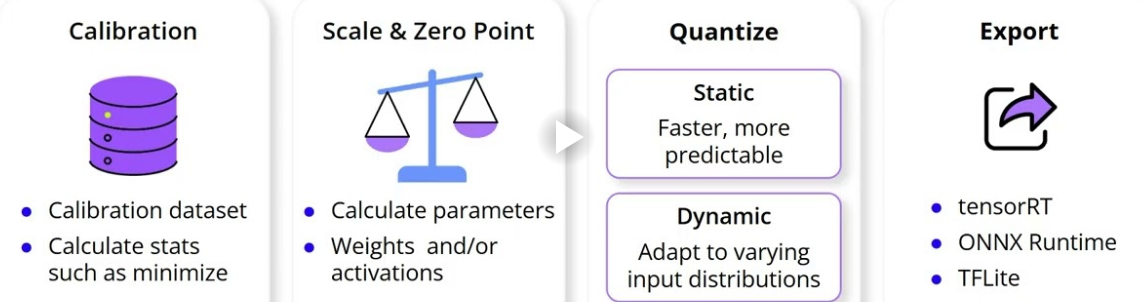

| Step                         | Short Explanation                                                     |
| ---------------------------- | --------------------------------------------------------------------- |
| Calibration                  | Run model on small sample data to collect activation ranges (min/max) |
| Calculate Scale & Zero-Point | Compute mapping from FP32 → INT8                                      |
| Quantization                 | Convert weights/activations into INT8 values                          |
| Static Quantization          | Fixed scale/zero-point from calibration → faster inference            |
| Dynamic Quantization         | Compute scale/zero-point during runtime → more adaptive               |
| Export                       | Save model for inference engines like TensorRT, ONNX Runtime, TFLite  |


post-training static quantization not working well. Reasons:
- Poor calibration → bad scale/zero-point → lower accuracy/performance
- FP32 fallback → some layers still run in FP32 → speedup reduced

| Possible Issue          | Why It Happens                                      | How to Verify                                                  |
| ----------------------- | --------------------------------------------------- | -------------------------------------------------------------- |
| Bad Calibration Dataset | Calibration data doesn’t match real production data | Compare calibration data distribution with real inference data |
| FP32 Fallbacks          | Some operators/layers don’t support INT8            | Check TensorRT/ONNX/TFLite logs for FP32 fallback warnings     |


### Frameworks for Quantization

* **Hugging Face Optimum** → High-level wrapper for ONNX Runtime, TensorRT, PyTorch quantization. Easy end-to-end PTQ/QAT workflows.
* **ONNX Runtime + Optimum-Intel** → Best for CPU deployment. Fast INT8 inference with simple setup.
* **TensorRT** → Best for NVIDIA GPUs when ultra-low latency is the goal. Deep GPU optimizations.
* **bitsandbytes** → Best for GPU memory efficiency. Run 4-bit/8-bit models with minimal code changes.
* **PyTorch Native Quantization** (`torch.quantization`) → Best for full control and custom quantization workflows.

### Simple Decision Flow

1. **Hardware?** → CPU or GPU
2. **Main bottleneck?** → Latency, memory, or simplicity
3. **Choose tool:**

   * CPU → ONNX Runtime
   * GPU + speed → TensorRT
   * GPU + low memory → bitsandbytes
   * Custom control → PyTorch APIs


for start in range(0, len(input_ids) - 1 - seq_len, seq_len):
        chunk = input_ids[start:start+seq_len+1]
        inp = chunk[:-1].unsqueeze(0).to(DEVICE)
        labels = chunk[1:].unsqueeze(0).to(DEVICE)

        out = model(input_ids=inp, labels=labels)
        nll_sum += float(out.loss) * labels.numel()
        tok_count += labels.numel()

    return math.exp(nll_sum / max(1, tok_count))

In [ ]:
# --- 3) Baseline: FP32 --------------------------------------------------------
print("\\n== Baseline FP32 ==")
baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True,
)
baseline_model.to(DEVICE)

In [ ]:
# Optimum (Quanto) for post-training quantization (static, weight-only int8)
from optimum.quanto import quantize, freeze, qint8

# --- 4) Post-Training Quantization: 8-bit (static, weight-only) --------------
# Fresh load in FP32, then quantize weights to int8 via Optimum-Quanto.
print("\n== PTQ INT8 (Optimum-Quanto, weight-only) ==")
q_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True,
)

# Static PTQ (weight-only): no calibration set required.
# This converts Linear weights to int8-packed format and wires quant/dequant where needed.
quantize(q_model, weights=qint8)
freeze(q_model)               # finalize quantization graphs / params
q_model.to(DEVICE)

Notice the result: the model size shrinks dramatically, but latency is higher and throughput is lower. This happens because the T4 GPU used for the demo lacks optimized compute kernels for this INT8 format, and the overhead of converting data types outweighs the benefits.

### CPU quantization, where INT8 support is more mature

Post-training quantization can significantly speed up CPU inference, but performance gains on GPUs depend heavily on the specific hardware's support for INT8 kernels.

In [ ]:
from torch.ao.quantization import quantize_dynamic
model_fp32 = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32).to(DEVICE).eval()
model_fp32.config.use_cache = True

# -----------------------------
# Quantized: INT8 dynamic (CPU)
# -----------------------------
# Quantize only Linear layers to int8 (native PyTorch). This is weight-only int8 + dynamic activation quant.
model_int8 = quantize_dynamic(
    model_fp32.cpu(),
    {torch.nn.Linear},
    dtype=torch.qint8
).eval()

| Metric           | GPU FP32 Baseline | GPU INT8 PTQ (Quanto) | CPU FP32   | CPU INT8 Dynamic |
| ---------------- | ----------------- | --------------------- | ---------- | ---------------- |
| Model Size       | 4200.3 MB         | 1242.5 MB             | —          | —                |
| Latency          | 2.644 s           | 6.658 s               | 0.611 s    | 0.220 s          |
| Throughput       | 48.42 tok/s       | 19.23 tok/s           | 1.66 tok/s | 4.55 tok/s       |
| Peak VRAM        | 4212.9 MB         | 5765.4 MB             | —          | —                |
| Perplexity (PPL) | 1.00              | 1.00                  | —          | —                |
| Speedup          | 1×                | Slower than FP32      | 1×         | 2.78× faster     |

1. GPU INT8 quantization reduced model size drastically (4200 MB → 1242 MB) with almost no quality loss (same PPL).

2. Despite compression, INT8 on T4 GPU became slower because the GPU lacked optimized INT8 kernels, causing quant/dequant overhead.

3. GPU FP32 achieved the highest throughput (48.42 tok/s), much higher than CPU throughput.

4. CPU throughput is lower overall because CPUs process tensor operations far less parallelly than GPUs. (20-40× slower)

5. Dynamic INT8 quantization on CPU still gave strong improvement: latency reduced from 0.611s → 0.220s and throughput increased from 1.66 → 4.55 tok/s (2.78× speedup).


Yes, model size and VRAM usage are related, but they are not the same.

* **Model size** = storage space for weights on disk.
* **VRAM usage** = total GPU memory used during inference.

Smaller models often use less VRAM, but VRAM also includes activations, KV cache, and temporary buffers.

In your case:

* Model size decreased after INT8 quantization. => 4200 MB → 1242 MB
* But VRAM increased due to extra quantization-related buffers and conversions on the GPU. => 4212.9 MB → 5765.4 MB

In [ ]:
q_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
    low_cpu_mem_usage=True,
)

# Static PTQ (weight-only): no calibration set required.
quantize(q_model, weights=qint8)
freeze(q_model)               # finalize quantization graphs / params
q_model.to(DEVICE)

In [ ]:
DEVICE = "cpu"
PROMPT = "Quantization test: explain why int8 dynamic quantization can be faster on CPU."
# ... (model loading and measurement calls are omitted for brevity)

# Quantize only Linear layers to int8 (native PyTorch).
model_int8 = quantize_dynamic(
    model_fp32.cpu(), {torch.nn.Linear}, dtype=torch.qint8
).eval()


| Precision      | Size (MB) | Latency @64 | TPS @64    | Latency @256 | TPS @256   | Avg PPLX |
| -------------- | --------- | ----------- | ---------- | ------------ | ---------- | -------- |
| FP32           | 4198.6    | 0.77s       | 1.32 tok/s | 0.69s        | 1.45 tok/s | 3388.10  |
| INT8-dyn (CPU) | 1239.3    | 0.17s       | 7.47 tok/s | 0.23s        | 4.43 tok/s | 3526.66  |

### Key Insights

* INT8 reduced model size by ~70%.
* INT8 achieved ~5.6× higher throughput at 64 tokens.
* INT8 latency improved significantly for short generations.
* Throughput dropped at 256 tokens due to longer decoding overhead.
* Perplexity increased only slightly, meaning quality was mostly preserved.


INT8 throughput is significantly higher than FP32.
Throughput decreases as generation length increases.
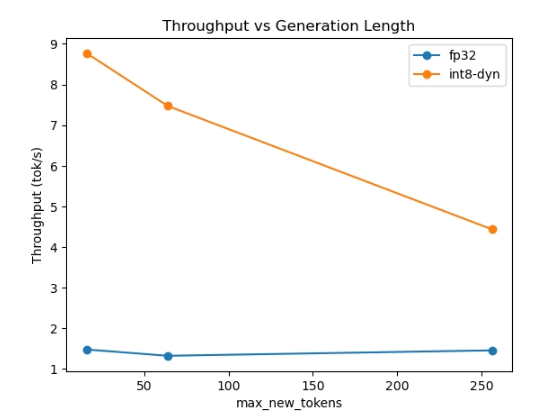

### Quantization-Aware Training (QAT)

QAT recovers accuracy lost during quantization by simulating low-precision noise during a brief fine-tuning phase, allowing the model to learn weights robust to rounding errors.  

The core mechanism involves simulating quantization noise during the forward pass of training. This is achieved through two key techniques:

- Fake-Quant Modules: Key layers in the model are wrapped with operators that mimic low-bit inference. During training, these modules take full-precision weights and activations, quantize them to the target bit-width (e.g., INT8), and then immediately de-quantize them back to floating-point. This injects realistic rounding errors, forcing the network to "feel" the effects of quantization.

- Straight-Through Estimator (STE): Since the rounding operation within quantization is non-differentiable, standard backpropagation would fail. The STE is a trick that allows gradients to flow through the fake-quant module as if it were an identity function, enabling the underlying floating-point parameters to be updated and learn from the quantization noise

 Quantization-Aware Training (QAT)

* QAT trains the model while simulating low-bit quantization (INT8/INT4) during training itself.
* The model learns to compensate for rounding and scaling errors introduced by quantization.
* Goal of QAT is achieving low-bit efficiency with near-FP32 accuracy.

 
 QAT vs PTQ

* PTQ applies quantization after training and may lose accuracy.
* QAT applies quantization during training so the model adapts to quantization noise.
* PTQ is faster and cheaper, while QAT needs extra training and compute.
* PTQ is good for quick deployment, while QAT is better for high-accuracy systems.

 
Core Idea of QAT

* During forward pass, FP32 values are temporarily quantized to low-bit format and then converted back to float.
* The network experiences quantization noise during training and learns robustness against it.
* This helps the final low-bit model behave similarly to the original FP32 model.
 

 Fake Quantization

* Fake-quant modules simulate INT8/INT4 arithmetic during training.
* They apply scale, zero-point adjustment, rounding, and dequantization.
* During training, these modules take full-precision weights and activations, quantize them to the target bit-width (e.g., INT8), and then immediately de-quantize them back to floating-point. 
* This injects realistic rounding errors, forcing the network to "feel" the effects of quantization.
* Computation still happens in floating point, but quantization effects are preserved.
 

 Straight-Through Estimator (STE)

* Rounding operations are non-differentiable, which blocks gradient flow.
* STE bypasses this by copying gradients through quantization operations during backpropagation,as if it were an identity function
* This allows the model to continue learning normally despite fake quantization.

The typical QAT workflow involves starting with a pre-trained model, preparing it for QAT, fine-tuning for a few epochs (usually 1-5) on a representative dataset, and then converting it to a final, truly low-precision model for deployment.

You should choose QAT over PTQ in three primary scenarios:

- Significant Accuracy Drop: When a simple PTQ pass causes model accuracy to fall by more than 2-3%.
- Challenging Data Dynamics: If your input data contains extreme outliers or is expected to shift over time, QAT helps the model become more robust.
- High-Fidelity Requirements: For safety-critical applications like medical imaging, autonomous systems, or financial forecasting, where even small errors are unacceptable.
- While QAT requires additional compute time and a fine-tuning dataset, the investment pays off by recovering 95-99% of the original FP32 model accuracy. However, the gains diminish after a few epochs, so it's a trade-off between training cost and the final inference performance.

#### Comparison Summary

| Aspect                    | PTQ             | QAT                 |
| ------------------------- | --------------- | ------------------- |
| When quantization happens | After training  | During training     |
| Accuracy recovery         | Limited         | Very high           |
| Extra training needed     | No              | Yes                 |
| Compute cost              | Low             | Higher              |
| Best for                  | Fast deployment | High accuracy needs |


Final Takeaway
- PTQ = fast but may lose accuracy.
- QAT = slightly expensive training, but near-FP32 performance.
- Best choice when accuracy matters more than training cost.